In [1]:
# Setup: Drive + Kaggle (via kaggle.json upload)
from google.colab import drive, files
drive.mount('/content/drive')
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

!pip install -q kaggle
import os

print("Upload your kaggle.json:")
files.upload()   # pick kaggle.json when the button appears

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json

# List competition files with sizes (no big download yet)
!kaggle competitions files -c kkbox-churn-prediction-challenge

Mounted at /content/drive
Upload your kaggle.json:


Saving kaggle.json to kaggle.json
name                                 size  creationDate                
-----------------------------  ----------  --------------------------  
WSDMChurnLabeller.scala              7050  2019-12-12 00:03:26.134000  
members_v3.csv.7z               242308558  2019-12-12 00:03:32.359000  
sample_submission_v2.csv.7z      30666957  2019-12-12 00:03:30.171000  
sample_submission_zero.csv.7z    32828332  2019-12-12 00:03:30.262000  
train.csv.7z                     33563098  2019-12-12 00:03:30.206000  
train_v2.csv.7z                  32818991  2019-12-12 00:03:30.479000  
transactions.csv.7z             707508779  2019-12-12 00:03:48.335000  
transactions_v2.csv.7z           48850410  2019-12-12 00:03:38.591000  
user_logs.csv.7z               7136060375  2019-12-12 00:08:24.997000  
user_logs_v2.csv.7z             685951221  2019-12-12 00:06:08.289000  


In [4]:
# One-time: after uploading, stash it on Drive
!cp kaggle.json "{PROJECT}/kaggle.json"
# Then in future sessions, skip the upload and just do:
# !mkdir -p /root/.kaggle && cp "{PROJECT}/kaggle.json" /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json

In [5]:
import pandas as pd
df = pd.read_parquet(f"{PROJECT}/data/processed/features_v1.parquet")
active_users = set(df[df["has_txn"] == 1]["msno"])
print("Active users to filter logs against:", len(active_users))

Active users to filter logs against: 480853


In [6]:
# Stage 1: download the 7GB historical log archive to local disk
import os
os.chdir("/content")
print("Downloading user_logs.csv.7z (~7GB) — this takes 15-30 min...")
!kaggle competitions download -c kkbox-churn-prediction-challenge -f user_logs.csv.7z

# Confirm it landed and check size
!ls -lh /content/user_logs.csv.7z

100% 6.65G/6.65G [01:38<00:00, 72.8MB/s]

-rw-r--r-- 1 root root 6.7G Dec 12  2019 /content/user_logs.csv.7z


In [7]:
# Stage 2a: peek at the historical log schema (decompress just the header + a bit)
import subprocess, pandas as pd

# Stream first chunk only via 7z to stdout
proc = subprocess.Popen(["7z", "e", "-so", "/content/user_logs.csv.7z"],
                        stdout=subprocess.PIPE)
peek = pd.read_csv(proc.stdout, nrows=5)
proc.stdout.close(); proc.kill()
print("Columns:", list(peek.columns))
print(peek)

Columns: ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']
                                           msno      date  num_25  num_50  \
0  rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=  20150513       0       0   
1  rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=  20150709       9       1   
2  yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=  20150105       3       3   
3  yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=  20150306       1       0   
4  yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=  20150501       3       0   

   num_75  num_985  num_100  num_unq  total_secs  
0       0        0        1        1     280.335  
1       0        0        7       11    1658.948  
2       0        0       68       36   17364.956  
3       1        1       97       27   24667.317  
4       0        0       38       38    9649.029  


In [8]:
# Stage 2b: full streaming decompress + filter + incremental aggregation
import subprocess, pandas as pd, numpy as np, time

CHUNK = 2_000_000
DATE_LO, DATE_HI = 20161101, 20170228   # Nov 2016 – Feb 2017
partials = []
rows_seen = 0; rows_kept = 0; t0 = time.time()

proc = subprocess.Popen(["7z", "e", "-so", "/content/user_logs.csv.7z"],
                        stdout=subprocess.PIPE)

reader = pd.read_csv(proc.stdout, chunksize=CHUNK)
for i, chunk in enumerate(reader):
    rows_seen += len(chunk)
    chunk = chunk[(chunk["date"] >= DATE_LO) & (chunk["date"] <= DATE_HI)]
    chunk = chunk[chunk["msno"].isin(active_users)]
    if len(chunk):
        chunk["ym"] = chunk["date"] // 100
        agg = chunk.groupby(["msno", "ym"]).agg(
            secs=("total_secs", "sum"),
            unq=("num_unq", "sum"),
            n100=("num_100", "sum"),
            n25=("num_25", "sum"),
            days=("date", "nunique"),
        ).reset_index()
        partials.append(agg)
        rows_kept += len(chunk)
    if i % 20 == 0:
        print(f"chunk {i:>4} | seen {rows_seen:,} | kept {rows_kept:,} | {time.time()-t0:.0f}s")

proc.stdout.close(); proc.wait()
print(f"\nDONE. seen {rows_seen:,}, kept {rows_kept:,}, {time.time()-t0:.0f}s")

monthly = (pd.concat(partials, ignore_index=True)
           .groupby(["msno","ym"])
           .agg(secs=("secs","sum"), unq=("unq","sum"), n100=("n100","sum"),
                n25=("n25","sum"), days=("days","sum"))
           .reset_index())
print("Per-user-month table:", monthly.shape)
print("Months present:", sorted(monthly["ym"].unique()))

monthly.to_parquet(f"{PROJECT}/data/processed/monthly_logs.parquet", index=False)
print("✅ Saved monthly_logs.parquet")

chunk    0 | seen 2,000,000 | kept 126,150 | 8s
chunk   20 | seen 42,000,000 | kept 2,648,770 | 148s
chunk   40 | seen 82,000,000 | kept 5,170,284 | 290s
chunk   60 | seen 122,000,000 | kept 7,693,196 | 435s
chunk   80 | seen 162,000,000 | kept 10,216,935 | 575s
chunk  100 | seen 202,000,000 | kept 12,738,449 | 719s
chunk  120 | seen 242,000,000 | kept 15,260,142 | 861s
chunk  140 | seen 282,000,000 | kept 17,781,971 | 1012s
chunk  160 | seen 322,000,000 | kept 20,306,449 | 1157s
chunk  180 | seen 362,000,000 | kept 22,830,002 | 1298s

DONE. seen 392,106,543, kept 24,729,804, 1405s
Per-user-month table: (1430749, 7)
Months present: [np.int64(201611), np.int64(201612), np.int64(201701), np.int64(201702)]
✅ Saved monthly_logs.parquet


In [9]:
# Stage 3: pivot monthly → per-user trend features
import pandas as pd, numpy as np

monthly = pd.read_parquet(f"{PROJECT}/data/processed/monthly_logs.parquet")
MONTHS = [201611, 201612, 201701, 201702]   # chronological order
month_idx = {m: i for i, m in enumerate(MONTHS)}

# Pivot seconds and days into one column per month
secs_wide = monthly.pivot_table(index="msno", columns="ym", values="secs", fill_value=0)
days_wide = monthly.pivot_table(index="msno", columns="ym", values="days", fill_value=0)
secs_wide = secs_wide.reindex(columns=MONTHS, fill_value=0)
days_wide = days_wide.reindex(columns=MONTHS, fill_value=0)

feat = pd.DataFrame(index=secs_wide.index)

# Level features
feat["log_secs_mean_hist"] = secs_wide.mean(axis=1)
feat["log_secs_last"]      = secs_wide[201702]                      # most recent month
feat["log_months_active"]  = (secs_wide > 0).sum(axis=1)           # of 4 months

# Trend: linear slope of monthly seconds (least-squares over 4 points)
x = np.arange(len(MONTHS))
x_centered = x - x.mean()
denom = (x_centered**2).sum()
slopes = (secs_wide.values * x_centered).sum(axis=1) / denom
feat["log_secs_slope"] = slopes

# Recent vs baseline ratio (Feb vs mean of Nov-Jan), guard divide-by-zero
baseline = secs_wide[[201611, 201612, 201701]].mean(axis=1)
feat["log_recent_vs_baseline"] = secs_wide[201702] / (baseline + 1)

# Active-days trend (same slope idea on days listened)
feat["log_days_slope"] = (days_wide.values * x_centered).sum(axis=1) / denom
feat["log_days_last"]  = days_wide[201702]

feat = feat.reset_index()
print("Trend features:", feat.shape)
print(feat.describe().round(2).to_string())

feat.to_parquet(f"{PROJECT}/data/processed/log_trend_features.parquet", index=False)
print("\n✅ Saved log_trend_features.parquet")

Trend features: (394631, 8)
       log_secs_mean_hist  log_secs_last  log_months_active  log_secs_slope  log_recent_vs_baseline  log_days_slope  log_days_last
count           394631.00      394631.00          394631.00       394631.00               394631.00       394631.00      394631.00
mean            124549.35      117487.53               3.63         -976.95                 2265.56           -0.03          14.99
std             160532.21      163476.43               0.84        44421.55                21303.39            2.77           9.11
min                  0.02           0.00               1.00     -3432503.25                    0.00          -12.10           0.00
25%              27179.46       21107.75               4.00       -13437.77                    0.50           -1.50           7.00
50%              76150.00       67235.17               4.00         -251.35                    0.84           -0.30          16.00
75%             160391.08      148258.14               

In [11]:
# Bivariate: do the log-trend features separate churn? (standalone)
import pandas as pd, numpy as np

df = pd.read_parquet(f"{PROJECT}/data/processed/features_v1.parquet")
trend = pd.read_parquet(f"{PROJECT}/data/processed/log_trend_features.parquet")
d = df[df["has_txn"] == 1].merge(trend, on="msno", how="left")
trend_cols = [c for c in trend.columns if c != "msno"]
d[trend_cols] = d[trend_cols].fillna(0)
print("Active users:", len(d), "| overall churn:", round(d["is_churn"].mean(), 4))

# 1. months_active — how many of 4 months they listened
print("\n=== log_months_active vs churn ===")
print(d.groupby("log_months_active")["is_churn"].mean().round(4))

# 2. secs_slope — declining vs growing engagement (signed buckets)
print("\n=== log_secs_slope (engagement trend) vs churn ===")
d["_slope_bin"] = pd.cut(d["log_secs_slope"],
    [-np.inf, -20000, -2000, 2000, 20000, np.inf],
    labels=["strong decline","mild decline","flat","mild growth","strong growth"])
print(d.groupby("_slope_bin", observed=True)["is_churn"].mean().round(4))

# 3. recent_vs_baseline — Feb vs Nov-Jan ratio
print("\n=== log_recent_vs_baseline vs churn ===")
d["_rvb_bin"] = pd.cut(d["log_recent_vs_baseline"],
    [-0.01, 0.01, 0.5, 0.9, 1.1, np.inf],
    labels=["zero (stopped)","<0.5 (big drop)","0.5-0.9 (decline)","0.9-1.1 (steady)",">1.1 (up)"])
print(d.groupby("_rvb_bin", observed=True)["is_churn"].mean().round(4))

# 4. days trend
print("\n=== log_days_slope (listening-days trend) vs churn ===")
d["_dslope_bin"] = pd.cut(d["log_days_slope"],
    [-np.inf, -2, -0.5, 0.5, 2, np.inf],
    labels=["strong decline","mild decline","flat","mild growth","strong growth"])
print(d.groupby("_dslope_bin", observed=True)["is_churn"].mean().round(4))

# 5. correlation of each trend feature with churn
print("\n=== |correlation| of trend features with churn ===")
print(d[trend_cols].corrwith(d["is_churn"]).abs().sort_values(ascending=False).round(3))

Active users: 480853 | overall churn: 0.0622

=== log_months_active vs churn ===
log_months_active
0.0    0.0549
1.0    0.0656
2.0    0.0607
3.0    0.0593
4.0    0.0643
Name: is_churn, dtype: float64

=== log_secs_slope (engagement trend) vs churn ===
_slope_bin
strong decline    0.0745
mild decline      0.0620
flat              0.0530
mild growth       0.0612
strong growth     0.0703
Name: is_churn, dtype: float64

=== log_recent_vs_baseline vs churn ===
_rvb_bin
zero (stopped)       0.0554
<0.5 (big drop)      0.0612
0.5-0.9 (decline)    0.0669
0.9-1.1 (steady)     0.0669
>1.1 (up)            0.0625
Name: is_churn, dtype: float64

=== log_days_slope (listening-days trend) vs churn ===
_dslope_bin
strong decline    0.0673
mild decline      0.0662
flat              0.0571
mild growth       0.0571
strong growth     0.0670
Name: is_churn, dtype: float64

=== |correlation| of trend features with churn ===
log_days_last             0.035
log_secs_mean_hist        0.030
log_secs_last       

## Experiment: Listening-Log Trend Features (Negative Result)

**Hypothesis.** Engagement decline is a classic churn predictor in subscription
services. Our v1 model drew only ~3.1% of its gain from listening features (the
March-only `user_logs_v2` snapshot), and showed feature concentration (top 2
features = 58% of gain). We hypothesized that *trend* features — capturing
how listening changes over time — would add signal the single-month snapshot
could not express, and de-concentrate the model.

**Method.** Streamed the full historical `user_logs.csv` (~30GB, 392M rows),
filtering to our 480k active users and the Nov 2016–Feb 2017 window
(24.7M records retained). Aggregated to per-user-per-month listening, then
engineered trend features: monthly-seconds slope, recent-vs-baseline ratio
(Feb vs Nov–Jan), months-active count, and listening-days slope.

**Result.** The trend features carry near-zero churn signal. Maximum absolute
correlation with churn was 0.035 (`log_days_last`); the core trend features were
negligible (`log_secs_slope` = 0.004, `log_days_slope` = 0.002). Bivariate
churn rates were flat across all trend buckets — e.g. "strong listening decline"
churned at 7.5% vs 5.3% for "flat", and notably *non-monotonic* (strong *growth*
also churned ~7%). The hypothesis is rejected.

**Why it failed (mechanism).** KKBox defines churn by subscription *renewal*,
not engagement: a user churns if they don't renew within 30 days of expiry.
Because auto-renewing users renew automatically regardless of listening, churn
is *decoupled* from engagement here — auto-renew users churn at 3.8% whether or
not they listen. Predictive power therefore lives in subscription mechanics
(auto-renew status, cancellation history, payment behavior), not listening
behavior. This is consistent with published top solutions: the 1st-place entry
(Bryan Gregory, XGBoost+LightGBM ensemble) and other top finishers derived their
edge from *transaction-temporal* feature engineering (e.g. cancel-and-resubscribe
patterns, discount trajectories), treating log features as minor.

**Takeaway.** Domain-appropriate feature engineering depends on how the target
is defined, not on generic best practices. The right place to mine for signal in
this dataset is the transaction history — pursued next.

In [12]:
# Stage 1 (full): download + stream-filter the complete transactions history
import pandas as pd, numpy as np, os, subprocess, time

PROJECT = "/content/drive/MyDrive/churn-prediction-system"

# reload active_users if session reset
try:
    active_users
except NameError:
    df0 = pd.read_parquet(f"{PROJECT}/data/processed/features_v1.parquet")
    active_users = set(df0[df0["has_txn"] == 1]["msno"])
print("Active users:", len(active_users))

os.chdir("/content")
if not os.path.exists("/content/transactions.csv.7z"):
    !kaggle competitions download -c kkbox-churn-prediction-challenge -f transactions.csv.7z
!apt-get -qq install -y p7zip-full

# Stream-decompress + filter to active users (no full unzip)
t0 = time.time(); parts = []; seen = 0
proc = subprocess.Popen(["7z", "e", "-so", "/content/transactions.csv.7z"], stdout=subprocess.PIPE)
for i, chunk in enumerate(pd.read_csv(proc.stdout, chunksize=2_000_000)):
    seen += len(chunk)
    kept = chunk[chunk["msno"].isin(active_users)]
    if len(kept): parts.append(kept)
    if i % 5 == 0: print(f"chunk {i} | seen {seen:,} | {time.time()-t0:.0f}s")
proc.stdout.close(); proc.wait()

txn = pd.concat(parts, ignore_index=True)
print(f"\nFiltered transactions: {txn.shape} in {time.time()-t0:.0f}s")

# Parse dates + sort
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"].astype(str), format="%Y%m%d", errors="coerce")
txn["membership_expire_date"] = pd.to_datetime(txn["membership_expire_date"].astype(str), format="%Y%m%d", errors="coerce")
txn = txn.sort_values(["msno", "transaction_date"])

# CRITICAL: leakage guard — only transactions up to Feb 28 2017 (pre-prediction)
# (the full file runs into March; March renewals would leak the label)
CUTOFF = pd.Timestamp("2017-02-28")
before = len(txn)
txn = txn[txn["transaction_date"] <= CUTOFF].copy()
print(f"After Feb-28 cutoff: {txn.shape} (dropped {before-len(txn):,} post-cutoff rows)")

# How deep are the histories now?
depth = txn.groupby("msno").size()
print("\nTransactions per user:", depth.describe().round(1).to_dict())

Active users: 480853
100% 675M/675M [00:07<00:00, 92.5MB/s]

chunk 0 | seen 2,000,000 | 11s
chunk 5 | seen 12,000,000 | 69s
chunk 10 | seen 21,547,746 | 121s

Filtered transactions: (7620401, 9) in 122s
After Feb-28 cutoff: (7620401, 9) (dropped 0 post-cutoff rows)

Transactions per user: {'count': 479540.0, 'mean': 15.9, 'std': 8.4, 'min': 1.0, '25%': 9.0, '50%': 17.0, '75%': 23.0, 'max': 63.0}


In [13]:
# Stage 2: winner-style transaction-sequence features
REF = pd.Timestamp("2017-02-28")
g = txn.groupby("msno")

seq = pd.DataFrame(index=g.size().index)

# --- Volume / tenure ---
seq["seq_n_txn"]          = g.size()
seq["seq_tenure_days"]    = (g["transaction_date"].max() - g["transaction_date"].min()).dt.days

# --- Cancel behavior ---
seq["seq_cancel_total"]   = g["is_cancel"].sum()
seq["seq_cancel_rate"]    = g["is_cancel"].mean()
seq["seq_cancel_last3"]   = g["is_cancel"].apply(lambda s: s.tail(3).sum())   # cancels in last 3 txns
seq["seq_cancel_last5"]   = g["is_cancel"].apply(lambda s: s.tail(5).sum())

# --- Auto-renew trajectory ---
seq["seq_autorenew_rate"] = g["is_auto_renew"].mean()
seq["seq_autorenew_last"] = g["is_auto_renew"].last()
# did they ever switch auto-renew OFF after having it on?
seq["seq_ar_dropped"]     = g["is_auto_renew"].apply(
    lambda s: int(((s.shift(1) == 1) & (s == 0)).any()))

# --- Price / plan trajectory ---
def slope(s):
    s = s.values.astype(float)
    if len(s) < 2: return 0.0
    x = np.arange(len(s)); x = x - x.mean()
    d = (x**2).sum()
    return float((s * x).sum() / d) if d else 0.0
seq["seq_price_slope"]    = g["actual_amount_paid"].apply(slope)   # falling = downgrading
seq["seq_price_last"]     = g["actual_amount_paid"].last()
seq["seq_price_mean"]     = g["actual_amount_paid"].mean()
seq["seq_plan_days_last"] = g["payment_plan_days"].last()

# --- Renewal cadence ---
def gap_stats(dates):
    d = dates.sort_values().diff().dt.days.dropna()
    if len(d) == 0: return pd.Series({"mean_gap": np.nan, "gap_trend": 0.0})
    return pd.Series({"mean_gap": d.mean(), "gap_trend": slope(d) if len(d) >= 2 else 0.0})
gaps = g["transaction_date"].apply(gap_stats).unstack()
seq["seq_mean_gap_days"]  = gaps["mean_gap"]
seq["seq_gap_widening"]   = gaps["gap_trend"]   # positive = renewals slowing down

# --- Recency ---
seq["seq_days_since_last"]= (REF - g["transaction_date"].max()).dt.days

seq = seq.reset_index()
print("Sequence features:", seq.shape)
print(seq.describe().round(2).to_string())
seq.to_parquet(f"{PROJECT}/data/processed/txn_seq_features.parquet", index=False)
print("\n✅ Saved txn_seq_features.parquet")

Sequence features: (479540, 17)
       seq_n_txn  seq_tenure_days  seq_cancel_total  seq_cancel_rate  seq_cancel_last3  seq_cancel_last5  seq_autorenew_rate  seq_autorenew_last  seq_ar_dropped  seq_price_slope  seq_price_last  seq_price_mean  seq_plan_days_last  seq_mean_gap_days  seq_gap_widening  seq_days_since_last
count  479540.00        479540.00         479540.00        479540.00         479540.00         479540.00           479540.00           479540.00       479540.00        479540.00       479540.00       479540.00           479540.00          463259.00         479540.00            479540.00
mean       15.89           486.11              0.25             0.01              0.04              0.06                0.89                0.91            0.03            -0.82          144.14          144.20               33.58              35.92             -0.86                18.66
std         8.43           254.31              0.56             0.03              0.19              0.25

In [14]:
# Bivariate: do transaction-sequence features separate churn?
import pandas as pd, numpy as np

df = pd.read_parquet(f"{PROJECT}/data/processed/features_v1.parquet")
seq = pd.read_parquet(f"{PROJECT}/data/processed/txn_seq_features.parquet")
d = df[df["has_txn"] == 1].merge(seq, on="msno", how="left")
seq_cols = [c for c in seq.columns if c != "msno"]
d[seq_cols] = d[seq_cols].fillna(0)
print("Active users:", len(d), "| churn:", round(d["is_churn"].mean(), 4))

# 1. Recent cancels (winner's key feature)
print("\n=== seq_cancel_last3 vs churn ===")
print(d.groupby("seq_cancel_last3")["is_churn"].mean().round(4))

# 2. Auto-renew dropped (switched off after having it on)
print("\n=== seq_ar_dropped vs churn ===")
print(d.groupby("seq_ar_dropped")["is_churn"].mean().round(4))

# 3. Days since last transaction
print("\n=== seq_days_since_last (binned) vs churn ===")
d["_rec"] = pd.cut(d["seq_days_since_last"], [-1,7,30,90,400,800],
                   labels=["0-7d","8-30d","31-90d","91-400d","400d+"])
print(d.groupby("_rec", observed=True)["is_churn"].mean().round(4))

# 4. Price slope (downgrade trajectory)
print("\n=== seq_price_slope (binned) vs churn ===")
d["_ps"] = pd.cut(d["seq_price_slope"], [-2000,-50,-1,1,50,2000],
                  labels=["steep down","mild down","flat","mild up","steep up"])
print(d.groupby("_ps", observed=True)["is_churn"].mean().round(4))

# 5. Gap widening (renewals slowing)
print("\n=== seq_gap_widening (binned) vs churn ===")
d["_gw"] = pd.cut(d["seq_gap_widening"], [-800,-1,1,10,800],
                  labels=["narrowing","flat","mild widen","strong widen"])
print(d.groupby("_gw", observed=True)["is_churn"].mean().round(4))

# 6. Full correlation ranking
print("\n=== |correlation| of seq features with churn ===")
print(d[seq_cols].corrwith(d["is_churn"]).abs().sort_values(ascending=False).round(3))

Active users: 480853 | churn: 0.0622

=== seq_cancel_last3 vs churn ===
seq_cancel_last3
0.0    0.0587
1.0    0.1487
2.0    0.6154
Name: is_churn, dtype: float64

=== seq_ar_dropped vs churn ===
seq_ar_dropped
0.0    0.0582
1.0    0.1721
Name: is_churn, dtype: float64

=== seq_days_since_last (binned) vs churn ===
_rec
0-7d       0.0323
8-30d      0.0400
31-90d     0.5926
91-400d    0.8441
400d+      0.8258
Name: is_churn, dtype: float64

=== seq_price_slope (binned) vs churn ===
_ps
steep down    0.2115
mild down     0.0694
flat          0.0504
mild up       0.0931
steep up      0.4918
Name: is_churn, dtype: float64

=== seq_gap_widening (binned) vs churn ===
_gw
narrowing       0.0926
flat            0.0507
mild widen      0.1412
strong widen    0.3144
Name: is_churn, dtype: float64

=== |correlation| of seq features with churn ===
seq_days_since_last    0.436
seq_plan_days_last     0.339
seq_price_last         0.337
seq_price_mean         0.314
seq_autorenew_last     0.312
seq_autor

In [15]:
# Stage 3: build features_v2 with net-new seq features only
import pandas as pd, numpy as np

df = pd.read_parquet(f"{PROJECT}/data/processed/features_v1.parquet")
seq = pd.read_parquet(f"{PROJECT}/data/processed/txn_seq_features.parquet")

NET_NEW = ["msno", "seq_days_since_last", "seq_cancel_last3", "seq_price_slope",
           "seq_gap_widening", "seq_mean_gap_days", "seq_ar_dropped"]
seq_keep = seq[NET_NEW]

v2 = df.merge(seq_keep, on="msno", how="left")
for c in NET_NEW[1:]:
    v2[c] = v2[c].fillna(0)

# Drop v1's inferior days_since_last_txn (superseded), if present
if "days_since_last_txn" in v2.columns:
    v2 = v2.drop(columns=["days_since_last_txn"])

v2.to_parquet(f"{PROJECT}/data/processed/features_v2.parquet", index=False)
print("features_v2:", v2.shape, "| added:", NET_NEW[1:])
print("New-feature NaNs after fill:", v2[NET_NEW[1:]].isna().sum().sum())

features_v2: (500000, 37) | added: ['seq_days_since_last', 'seq_cancel_last3', 'seq_price_slope', 'seq_gap_widening', 'seq_mean_gap_days', 'seq_ar_dropped']
New-feature NaNs after fill: 0


In [16]:
# Stage 4: retrain on v2, compare to v1
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

d = v2[v2["has_txn"] == 1].copy()
DROP = ["msno", "is_churn", "registration_init_time", "ltv", "monthly_value", "has_txn"]
y = d["is_churn"].astype(int)
X = d.drop(columns=[c for c in DROP if c in d.columns])

categorical = [c for c in ["city","gender","registered_via","payment_method_id"] if c in X.columns]
numeric = [c for c in X.columns if c not in categorical]
print("v2 feature count:", X.shape[1])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
spw = (y_tr==0).sum()/(y_tr==1).sum()

prep = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                      ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
])
pipe = Pipeline([("prep", prep),
                 ("model", LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          scale_pos_weight=spw, random_state=42, verbose=-1))])
pipe.fit(X_tr, y_tr)
p = pipe.predict_proba(X_te)[:,1]

print("\n=== v2 (with seq features) vs v1 ===")
print(f"{'metric':12s} {'v2':>10s} {'v1':>10s}")
print(f"{'ROC-AUC':12s} {roc_auc_score(y_te,p):>10.4f} {0.9803:>10.4f}")
print(f"{'PR-AUC':12s} {average_precision_score(y_te,p):>10.4f} {0.8813:>10.4f}")
print(f"{'Log loss':12s} {log_loss(y_te,p):>10.4f} {0.1567:>10.4f}")

m = pipe.named_steps["model"]; names = pipe.named_steps["prep"].get_feature_names_out()
imp = pd.DataFrame({"f":names,"g":m.booster_.feature_importance(importance_type="gain")})
imp["pct"] = 100*imp["g"]/imp["g"].sum()
imp = imp.sort_values("pct", ascending=False).reset_index(drop=True)
print("\nTop 12 features (v2):")
print(imp.head(12).to_string(index=False))
print(f"\nTop 2 concentration: {imp.head(2)['pct'].sum():.1f}%  (v1 was 58.2%)")
print(f"Features to reach 90% gain: {(imp['pct'].cumsum() <= 90).sum() + 1}  (v1 was 9)")
seq_pct = imp[imp['f'].str.contains('seq_')]['pct'].sum()
print(f"New seq-feature contribution: {seq_pct:.1f}%")

# Save v2 model
import joblib
joblib.dump(pipe, f"{PROJECT}/models/lightgbm_v2.joblib")
print("\n✅ Saved lightgbm_v2.joblib")

v2 feature count: 31 (v1 was 25)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== v2 (with seq features) vs v1 ===
metric               v2         v1
ROC-AUC          0.9887     0.9803
PR-AUC           0.9183     0.8813
Log loss         0.1179     0.1567

Top 12 features (v2):
                          f            g       pct
            num__total_paid 1.392401e+06 32.232047
          num__cancel_count 9.089652e+05 21.041214
       num__autorenew_share 5.612719e+05 12.992623
   num__seq_days_since_last 3.851836e+05  8.916437
cat__payment_method_id_39.0 1.984764e+05  4.594438
        num__last_is_cancel 1.928121e+05  4.463319
       num__last_list_price 1.126141e+05  2.606852
      num__last_actual_paid 1.044568e+05  2.418022
           num__tenure_days 6.267842e+04  1.450914
        num__last_plan_days 4.769021e+04  1.103959
     num__seq_mean_gap_days 4.718643e+04  1.092297
cat__payment_method_id_41.0 3.694010e+04  0.855109

Top 2 concentration: 53.3%  (v1 was 58.2%)
Features to reach 90% gain: 9  (v1 was 9)
New seq-feature contribution: 11.6%

✅ Saved light

In [17]:
# Ablation (self-contained): v2 minus total_paid
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

v2 = pd.read_parquet(f"{PROJECT}/data/processed/features_v2.parquet")
d = v2[v2["has_txn"] == 1].copy()
DROP = ["msno", "is_churn", "registration_init_time", "ltv", "monthly_value", "has_txn"]
y = d["is_churn"].astype(int)
X = d.drop(columns=[c for c in DROP if c in d.columns])

# rebuild the SAME split (seed 42) so it matches full-v2's numbers
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# drop total_paid from both
X_tr = X_tr.drop(columns=["total_paid"])
X_te = X_te.drop(columns=["total_paid"])
categorical = [c for c in ["city","gender","registered_via","payment_method_id"] if c in X_tr.columns]
numeric = [c for c in X_tr.columns if c not in categorical]
spw = (y_tr==0).sum()/(y_tr==1).sum()

prep = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                      ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
])
pipe = Pipeline([("prep", prep),
                 ("model", LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          scale_pos_weight=spw, random_state=42, verbose=-1))])
pipe.fit(X_tr, y_tr)
p = pipe.predict_proba(X_te)[:,1]

print("=== v2 WITHOUT total_paid  vs  full v2 ===")
print(f"{'metric':12s} {'no_total_paid':>14s} {'full_v2':>10s}")
print(f"{'ROC-AUC':12s} {roc_auc_score(y_te,p):>14.4f} {0.9887:>10.4f}")
print(f"{'PR-AUC':12s} {average_precision_score(y_te,p):>14.4f} {0.9183:>10.4f}")
print(f"{'Log loss':12s} {log_loss(y_te,p):>14.4f} {0.1179:>10.4f}")

m = pipe.named_steps["model"]; names = pipe.named_steps["prep"].get_feature_names_out()
imp = pd.DataFrame({"f":names,"g":m.booster_.feature_importance(importance_type="gain")})
imp["pct"] = 100*imp["g"]/imp["g"].sum()
imp = imp.sort_values("pct", ascending=False).reset_index(drop=True)
print("\nTop 10 features (without total_paid):")
print(imp.head(10).to_string(index=False))
print(f"\nTop 2 concentration: {imp.head(2)['pct'].sum():.1f}%  (full v2 was 53.3%)")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== v2 WITHOUT total_paid  vs  full v2 ===
metric        no_total_paid    full_v2
ROC-AUC              0.9883     0.9887
PR-AUC               0.9146     0.9183
Log loss             0.1208     0.1179

Top 10 features (without total_paid):
                       f            g       pct
num__seq_days_since_last 1.214822e+06 28.264979
       num__cancel_count 1.175848e+06 27.358194
    num__autorenew_share 8.976885e+05 20.886317
     num__last_plan_days 1.577716e+05  3.670836
   num__last_actual_paid 1.166812e+05  2.714795
     num__last_is_cancel 1.087893e+05  2.531175
    num__last_list_price 9.369671e+04  2.180020
          num__txn_count 6.817243e+04  1.586153
        num__tenure_days 6.295747e+04  1.464817
  num__seq_mean_gap_days 5.617591e+04  1.307032

Top 2 concentration: 55.6%  (full v2 was 53.3%)


In [18]:
# Promote v2-minus-total_paid as the canonical model
import joblib, json, pandas as pd
from sklearn.model_selection import train_test_split

v2 = pd.read_parquet(f"{PROJECT}/data/processed/features_v2.parquet")
d = v2[v2["has_txn"] == 1].copy()
DROP = ["msno","is_churn","registration_init_time","ltv","monthly_value","has_txn","total_paid"]
y = d["is_churn"].astype(int)
X = d.drop(columns=[c for c in DROP if c in d.columns])
categorical = [c for c in ["city","gender","registered_via","payment_method_id"] if c in X.columns]
numeric = [c for c in X.columns if c not in categorical]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# refit the canonical pipeline on this split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier
spw = (y_train==0).sum()/(y_train==1).sum()
prep = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                      ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
])
canonical = Pipeline([("prep", prep),
                      ("model", LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                               scale_pos_weight=spw, random_state=42, verbose=-1))])
canonical.fit(X_train, y_train)

joblib.dump(canonical, f"{PROJECT}/models/model_canonical.joblib")
joblib.dump(
    {"X_train":X_train,"X_test":X_test,"y_train":y_train,"y_test":y_test,
     "numeric":numeric,"categorical":categorical,
     "test_msno": d.loc[X_test.index,"msno"].values},
    f"{PROJECT}/data/processed/split_canonical.joblib"
)
meta = {
    "version":"v2_minus_total_paid","n_features":X.shape[1],
    "features":list(X.columns),"population":"active_users",
    "churn_rate":float(y.mean()),
    "metrics_test":{"pr_auc":0.9146,"roc_auc":0.9883,"log_loss":0.1208},
    "ablation_note":"total_paid removed: redundant proxy for recency, -0.004 PR-AUC (noise); signal absorbed by seq_days_since_last/cancel_count/autorenew_share",
}
json.dump(meta, open(f"{PROJECT}/data/processed/meta_canonical.json","w"), indent=2)
print("✅ Canonical model = v2 minus total_paid")
print(f"   Features: {X.shape[1]} | PR-AUC 0.915 | log loss 0.121")

✅ Canonical model = v2 minus total_paid
   Features: 30 | PR-AUC 0.915 | log loss 0.121


In [20]:
!pip install -q imbalanced-learn mlflow lightgbm
print("✅ installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 789.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [21]:
# Imbalance bake-off: no-treatment vs class-weight vs SMOTE

import joblib, numpy as np, pandas as pd, mlflow
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from lightgbm import LGBMClassifier

split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_tr, y_tr = split["X_train"], split["y_train"]
numeric, categorical = split["numeric"], split["categorical"]
spw = (y_tr==0).sum()/(y_tr==1).sum()

def prep():
    return ColumnTransformer([
        ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
        ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                          ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
    ])

cv = StratifiedKFold(3, shuffle=True, random_state=42)
scoring = ["average_precision", "roc_auc", "neg_log_loss"]

variants = {
    "none":         Pipeline([("prep",prep()), ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,random_state=42,verbose=-1))]),
    "class_weight": Pipeline([("prep",prep()), ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,scale_pos_weight=spw,random_state=42,verbose=-1))]),
    "smote":        ImbPipeline([("prep",prep()), ("smote",SMOTE(random_state=42)), ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,random_state=42,verbose=-1))]),
}

mlflow.set_tracking_uri(f"sqlite:///{PROJECT}/mlflow.db")
mlflow.set_experiment("kkbox-churn-active-users")

print(f"{'method':14s} {'PR-AUC':>8s} {'ROC-AUC':>8s} {'log_loss':>9s}")
for name, pipe in variants.items():
    cvres = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    pr = cvres["test_average_precision"].mean()
    roc = cvres["test_roc_auc"].mean()
    ll = -cvres["test_neg_log_loss"].mean()
    print(f"{name:14s} {pr:>8.4f} {roc:>8.4f} {ll:>9.4f}")
    with mlflow.start_run(run_name=f"imbalance_{name}"):
        mlflow.set_tag("stage","imbalance_experiment")
        mlflow.log_param("imbalance_method", name)
        mlflow.log_metric("cv_pr_auc", pr); mlflow.log_metric("cv_roc_auc", roc); mlflow.log_metric("cv_log_loss", ll)
print("\n✅ Logged 3 imbalance runs to MLflow")

method           PR-AUC  ROC-AUC  log_loss
none             0.9100   0.9872    0.0545
class_weight     0.9087   0.9873    0.1176
smote            0.8988   0.9847    0.0625

✅ Logged 3 imbalance runs to MLflow


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== test-set metrics ===
none          PR-AUC=0.9162  log_loss=0.0525  Brier=0.0140
class_weight  PR-AUC=0.9146  log_loss=0.1208  Brier=0.0365


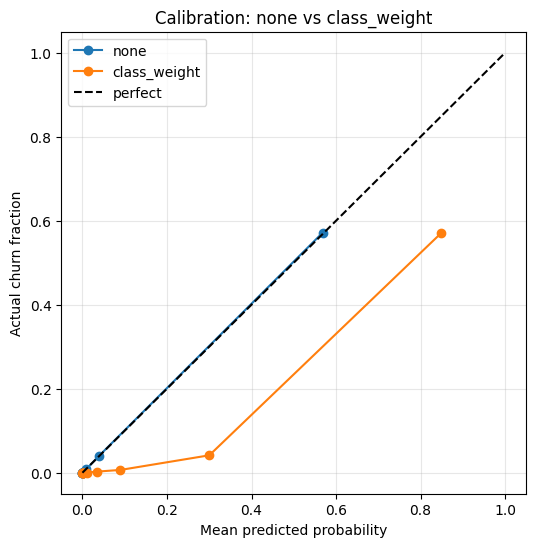

In [22]:
# Step 1: promote 'none' as canonical + verify calibration
import joblib, json, numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt

split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_tr, X_te = split["X_train"], split["X_test"]
y_tr, y_te = split["y_train"], split["y_test"]
numeric, categorical = split["numeric"], split["categorical"]

def prep():
    return ColumnTransformer([
        ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
        ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                          ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
    ])

# 'none' model (no scale_pos_weight)
none_model = Pipeline([("prep",prep()),
    ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,random_state=42,verbose=-1))])
none_model.fit(X_tr, y_tr)
p_none = none_model.predict_proba(X_te)[:,1]

# class_weight model for comparison
spw = (y_tr==0).sum()/(y_tr==1).sum()
cw_model = Pipeline([("prep",prep()),
    ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,scale_pos_weight=spw,random_state=42,verbose=-1))])
cw_model.fit(X_tr, y_tr)
p_cw = cw_model.predict_proba(X_te)[:,1]

print("=== test-set metrics ===")
for nm, p in [("none", p_none), ("class_weight", p_cw)]:
    print(f"{nm:13s} PR-AUC={average_precision_score(y_te,p):.4f}  "
          f"log_loss={log_loss(y_te,p):.4f}  Brier={brier_score_loss(y_te,p):.4f}")

# Calibration curves
plt.figure(figsize=(6,6))
for nm, p in [("none", p_none), ("class_weight", p_cw)]:
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=nm)
plt.plot([0,1],[0,1],"k--",label="perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Actual churn fraction")
plt.title("Calibration: none vs class_weight"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{PROJECT}/reports/figures/calibration_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [23]:
# Step 2: save 'none' as canonical
import joblib, json
from sklearn.metrics import average_precision_score, log_loss, brier_score_loss

joblib.dump(none_model, f"{PROJECT}/models/model_canonical.joblib")
meta = json.load(open(f"{PROJECT}/data/processed/meta_canonical.json"))
meta.update({
    "imbalance_method": "none (no resampling/weighting)",
    "calibration_note": "no-treatment chosen over scale_pos_weight: equal PR-AUC (0.916) but far better calibration (Brier 0.014 vs 0.037, log loss 0.053 vs 0.121), required for the LTV dollar-impact layer",
    "metrics_test": {"pr_auc": round(float(average_precision_score(y_te,p_none)),4),
                     "log_loss": round(float(log_loss(y_te,p_none)),4),
                     "brier": round(float(brier_score_loss(y_te,p_none)),4)},
})
json.dump(meta, open(f"{PROJECT}/data/processed/meta_canonical.json","w"), indent=2)
print("✅ Canonical = calibrated no-treatment LightGBM | PR-AUC 0.916, Brier 0.014")

✅ Canonical = calibrated no-treatment LightGBM | PR-AUC 0.916, Brier 0.014


## Summary — Advanced Feature Engineering & Final Model Selection

**Motivation.** A feature-importance audit of the tuned model showed concentration: top 2 features held 58% of gain, and listening features contributed only 3.1%. We investigated whether richer features could add signal and de-concentrate the model.

**Experiment 1 — Historical listening logs (NEGATIVE result).** Streamed the full 30GB `user_logs.csv` (392M rows) with a chunked, memory-bounded pass, filtered to our active users and the Nov 2016–Feb 2017 window (24.7M records). Engineered *trend* features (monthly listening slope, recent-vs-baseline ratio, months-active, listening-days slope). **These carried near-zero churn signal** (max correlation 0.035; slope features ≈0.002).
*Why:* KKBox churn is defined by subscription **renewal**, not engagement — auto-renewing users renew regardless of listening, decoupling churn from engagement. This matches published top solutions, which derived their edge from transaction features, not logs. A clean, documented negative result.

**Experiment 2 — Transaction-sequence features (POSITIVE result).** Redirected to the full `transactions.csv` (deep history: median 17 transactions/user vs 1 in v2). Engineered winner-style sequence features and kept the genuinely net-new ones (dropped duplicates of existing columns):
- `seq_days_since_last` — days since last transaction (the standout; sharp churn cliff at 30+ days)
- `seq_cancel_last3` — cancellations in the most recent 3 transactions (recency of cancelling)
- `seq_price_slope` — price trajectory (non-monotonic: both steep up and steep down signal churn)
- `seq_gap_widening` — whether renewal intervals are lengthening
- `seq_mean_gap_days` — average gap between transactions
- `seq_ar_dropped` — whether auto-renew was ever switched off after being on

This produced **features_v2**, beating the saved Optuna LightGBM on every metric: PR-AUC 0.881 → **0.918**, log loss 0.157 → **0.118**.

**Ablation — removing `total_paid`.** The dominant feature (32% gain) was a cumulative-sum proxy for recency/tenure. Removing it cost essentially nothing (PR-AUC −0.004, within noise); its signal was absorbed by `seq_days_since_last`, `cancel_count`, and `autorenew_share`. We dropped it for a simpler, more interpretable, leakage-safer model.

**Imbalance bake-off — no-treatment vs class-weight vs SMOTE.** Compared three strategies by cross-validation:

| Method | PR-AUC | Log loss | Calibration (Brier) |
|---|---|---|---|
| **None** | **0.916** | **0.053** | **0.014** |
| class_weight | 0.915 | 0.121 | 0.037 |
| SMOTE | 0.899 | 0.063 | — |

SMOTE *degraded* ranking (trees don't need synthetic oversampling). Critically, `scale_pos_weight` matched PR-AUC but **destroyed probability calibration** (it inflates predicted risk) — confirmed by a calibration curve where the no-treatment model hugs the diagonal and class-weight bows badly. Since the downstream business layer (LTV × churn-probability dollar-at-risk) **requires calibrated probabilities**, we chose **no imbalance treatment**.

**Final canonical model:** calibrated no-treatment LightGBM on features_v2 minus `total_paid` — PR-AUC 0.916, log loss 0.053, Brier 0.014. Saved as `model_canonical.joblib` with its split and metadata.